# **A Comparative Study of Machine Learning Algorithms for Stock Market Prediction Using Yahoo Finance Data**

In [1]:
!pip install yfinance pandas --quiet

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## Define NIFTY 500 ticker and fetch data

## **Data Loading**

In [3]:
ticker = "^NSEI"
df = yf.download(ticker, period="10y", interval="1d")

df = df.reset_index()
df.rename(columns={"Date": "Date"}, inplace=True)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df = df[["Open", "High", "Low", "Close", "Volume"]]

df = df.dropna()

/tmp/ipykernel_6531/3130246206.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="10y", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Open,High,Low,Close,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2016-05-02,7822.700195,7829.799805,7777.299805,7805.899902,146300
2016-05-03,7824.799805,7890.250000,7735.149902,7747.000000,186500
2016-05-04,7724.149902,7749.000000,7697.250000,7706.549805,199700
2016-05-05,7731.000000,7777.549805,7706.850098,7735.500000,185100
2016-05-06,7717.649902,7738.899902,7678.350098,7733.450195,163600


### Droping unwanted rows

In [5]:
df = df[df.index != "Ticker"]

In [6]:
df.columns = ["Close", "High", "Low", "Open", "Volume"]

In [7]:
if "Price" in df.columns:
    df = df.drop(columns=["Price"])

In [8]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [9]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2016-05-02,7822.700195,7829.799805,7777.299805,7805.899902,146300
2016-05-03,7824.799805,7890.250000,7735.149902,7747.000000,186500
2016-05-04,7724.149902,7749.000000,7697.250000,7706.549805,199700
2016-05-05,7731.000000,7777.549805,7706.850098,7735.500000,185100
2016-05-06,7717.649902,7738.899902,7678.350098,7733.450195,163600


In [10]:
df = df.dropna()

In [11]:
# Check for duplicates
duplicate_rows = df.duplicated()
print("Number of duplicated rows:", duplicate_rows.sum())


Number of duplicated rows: 0


## EDA

In [12]:
# Convert all columns to numeric (ignore errors for non-numeric)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check types
print(df.dtypes)

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [13]:
# Resample yearly and compute average
df_yearly = df.resample('YE').mean()
df_yearly

,Close,High,Low,Open,Volume
Date,,,,,
2016-12-31,8369.113531,8404.125003,8322.589758,8363.855128,183568.674699
2017-12-31,9596.844360,9625.885321,9554.504209,9590.717943,197560.483871
2018-12-31,10759.185128,10802.830389,10696.462640,10750.673270,250085.306122
2019-12-31,11447.320349,11498.030938,11373.915756,11435.851056,486908.713693
2020-12-31,11165.962994,11245.230777,11057.114398,11152.998207,655785.600000
2021-12-31,16042.683858,16118.128209,15928.560043,16026.760652,413992.741935
2022-12-31,17247.486903,17342.250835,17135.655844,17245.430463,278347.983871
2023-12-31,18909.807350,18971.875861,18819.878516,18900.591271,263406.530612
2024-12-31,23508.354063,23613.850649,23374.785005,23493.810340,313560.162602


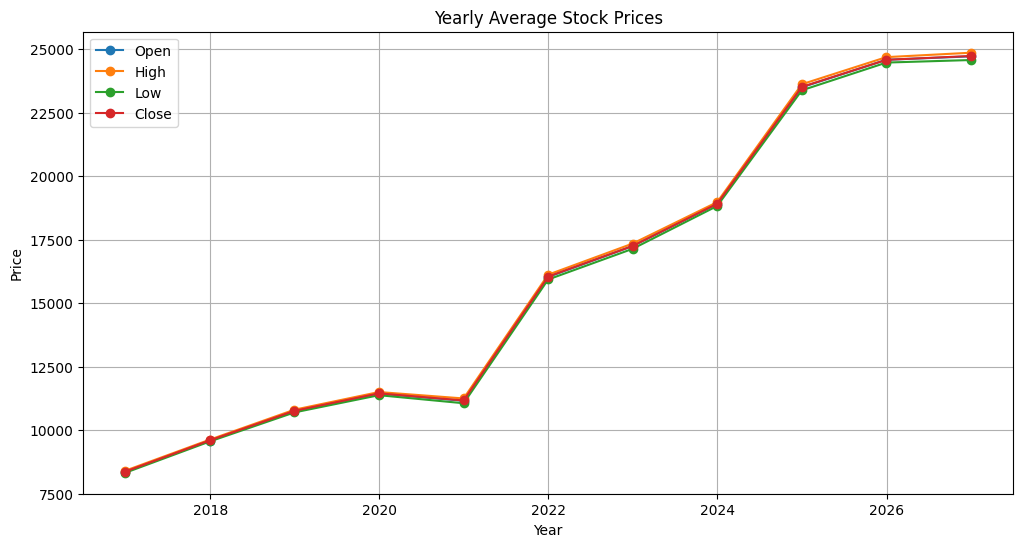

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df_yearly.index, df_yearly['Open'], marker='o', label='Open')
plt.plot(df_yearly.index, df_yearly['High'], marker='o', label='High')
plt.plot(df_yearly.index, df_yearly['Low'], marker='o', label='Low')
plt.plot(df_yearly.index, df_yearly['Close'], marker='o', label='Close')
plt.title('Yearly Average Stock Prices')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

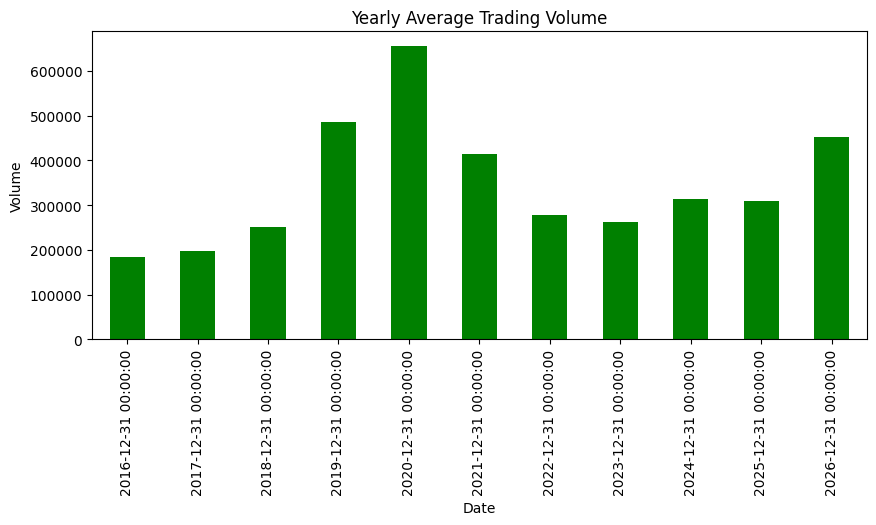

In [15]:
# Plot yearly average volume
plt.figure(figsize=(10,4))
df_yearly['Volume'].plot(kind='bar', color='green')
plt.title('Yearly Average Trading Volume')
plt.ylabel('Volume')
plt.show()

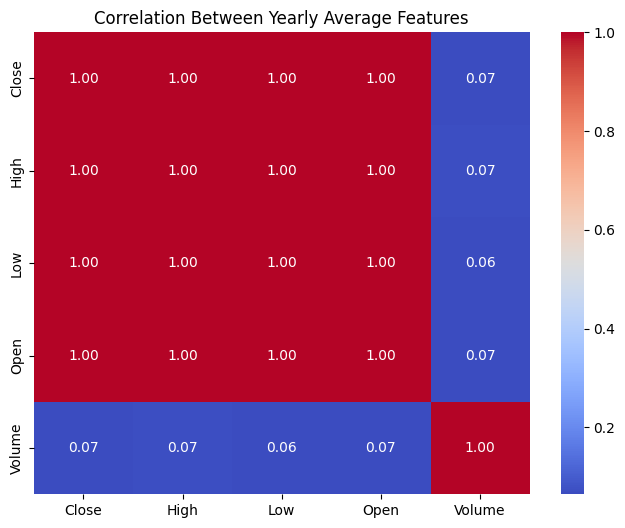

In [16]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df_yearly.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Yearly Average Features')
plt.show()

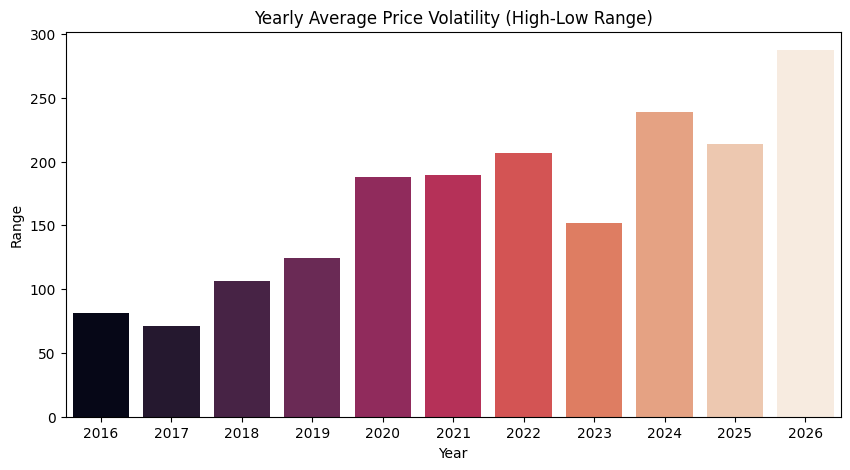

In [17]:
df_yearly['Range'] = df_yearly['High'] - df_yearly['Low']
plt.figure(figsize=(10,5))
sns.barplot(x=df_yearly.index.year, y=df_yearly['Range'], hue=df_yearly.index.year, palette='rocket', legend=False)
plt.title('Yearly Average Price Volatility (High-Low Range)')
plt.xlabel('Year')
plt.ylabel('Range')
plt.show()

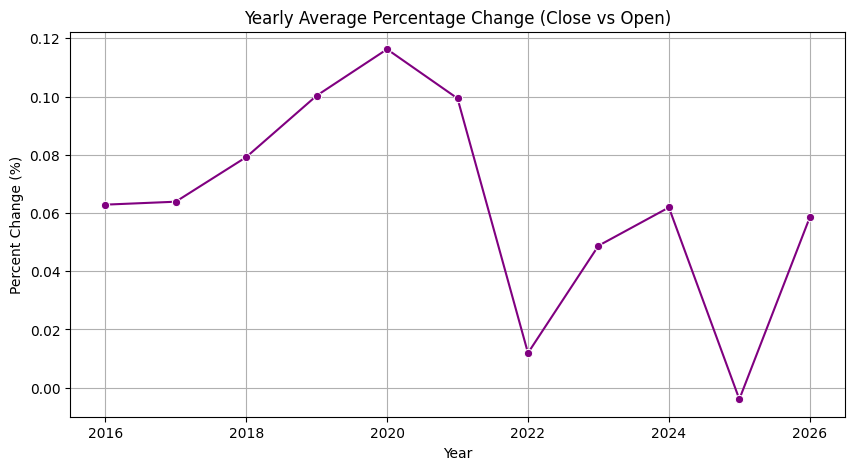

In [18]:
df_yearly['Pct_Change'] = ((df_yearly['Close'] - df_yearly['Open']) / df_yearly['Open']) * 100
plt.figure(figsize=(10,5))
sns.lineplot(x=df_yearly.index.year, y=df_yearly['Pct_Change'], marker='o', color='purple')
plt.title('Yearly Average Percentage Change (Close vs Open)')
plt.xlabel('Year')
plt.ylabel('Percent Change (%)')
plt.grid(True)
plt.show()

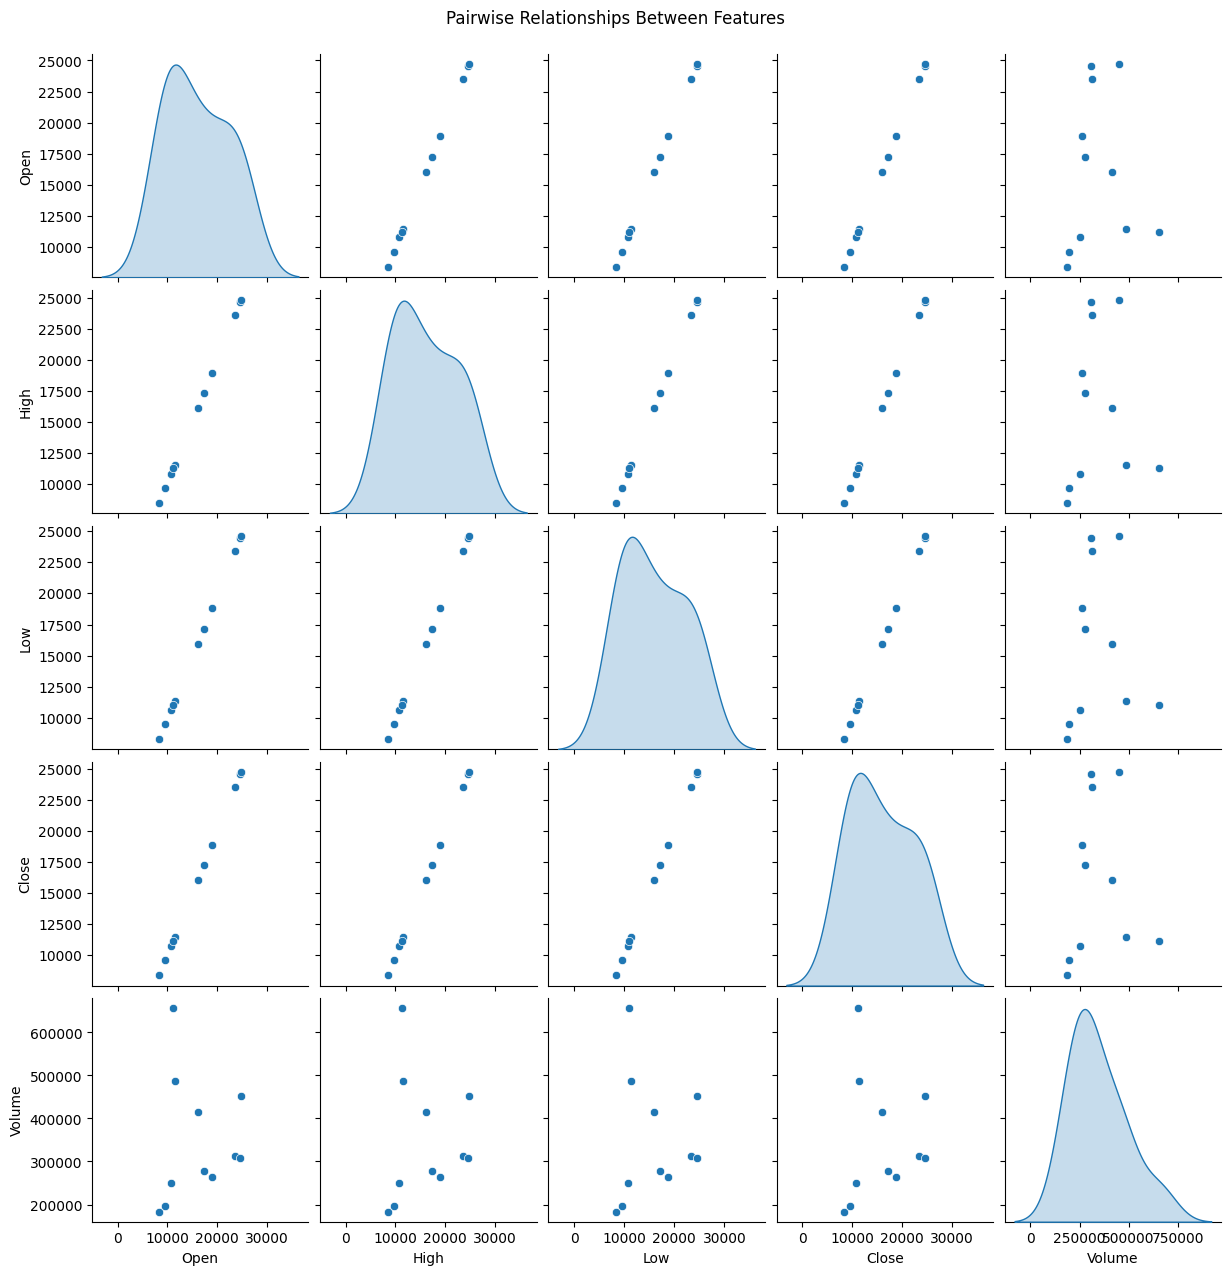

In [19]:
sns.pairplot(df_yearly[['Open','High','Low','Close','Volume']], kind='scatter', diag_kind='kde')
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

## **Data Split**

In [20]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

In [21]:
print(train_df.shape)
print(test_df.shape)

print(train_df.index.min(), "→", train_df.index.max())
print(test_df.index.min(), "→", test_df.index.max())

(1971, 5)
(493, 5)
2016-05-02 00:00:00 → 2024-04-30 00:00:00
2024-05-02 00:00:00 → 2026-04-29 00:00:00


## **Feature Engineering**

In [22]:
# Moving Averages
for dataset in [train_df, test_df]:
    dataset["MA_5"] = dataset["Close"].rolling(window=5).mean()
    dataset["MA_10"] = dataset["Close"].rolling(window=10).mean()

In [24]:
# RSI (Momentum Indicator)
def compute_rsi(data, window=14):
    delta = data["Close"].diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

for dataset in [train_df, test_df]:
    dataset["RSI"] = compute_rsi(dataset)

In [25]:
# MACD (Trend Indicator)
for dataset in [train_df, test_df]:
    ema12 = dataset["Close"].ewm(span=12, adjust=False).mean()
    ema26 = dataset["Close"].ewm(span=26, adjust=False).mean()

    dataset["MACD"] = ema12 - ema26
    dataset["MACD_Signal"] = dataset["MACD"].ewm(span=9, adjust=False).mean()

In [27]:
# Bollinger Bands (Volatility)
for dataset in [train_df, test_df]:
    ma20 = dataset["Close"].rolling(window=20).mean()
    std20 = dataset["Close"].rolling(window=20).std()

    dataset["BB_Upper"] = ma20 + (2 * std20)
    dataset["BB_Lower"] = ma20 - (2 * std20)

In [28]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [29]:
print(train_df.shape)
print(test_df.shape)
print(train_df.columns)

(1952, 12)
(474, 12)
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_10', 'RSI',
       'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower'],
      dtype='object')


## **Scaling**

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_df)

MinMaxScaler()

In [31]:
train_scaled = scaler.transform(train_df)
test_scaled = scaler.transform(test_df)

In [32]:
train_scaled = pd.DataFrame(train_scaled, columns=train_df.columns, index=train_df.index)
test_scaled = pd.DataFrame(test_scaled, columns=test_df.columns, index=test_df.index)

In [33]:
print(train_scaled.head())
print(test_scaled.head())

               Close      High       Low      Open    Volume      MA_5  \
Date                                                                     
2016-05-27  0.023074  0.013106  0.037325  0.036081  0.144064  0.000000   
2016-05-30  0.028699  0.015523  0.042189  0.037524  0.136610  0.004777   
2016-05-31  0.031584  0.016441  0.041101  0.036309  0.260077  0.011169   
2016-06-01  0.029544  0.016559  0.043525  0.037620  0.107344  0.016147   
2016-06-02  0.028061  0.017515  0.042450  0.040195  0.100331  0.018619   

               MA_10       RSI      MACD  MACD_Signal  BB_Upper  BB_Lower  
Date                                                                       
2016-05-27  0.000000  0.661052  0.713301     0.686309  0.000000  0.052454  
2016-05-30  0.002284  0.648475  0.727267     0.692765  0.004803  0.050005  
2016-05-31  0.004416  0.717397  0.740137     0.700958  0.009446  0.047986  
2016-06-01  0.006681  0.668684  0.748056     0.709377  0.012528  0.047963  
2016-06-02  0.008598  0.6

## **Sequence Creation (LSTM input)**

In [37]:
import numpy as np
def create_sequences(data, target_col="Close", timesteps=60):
    X, y = [], []

    values = data.values
    target_index = data.columns.get_loc(target_col)

    for i in range(timesteps, len(data)):
        X.append(values[i-timesteps:i])
        y.append(values[i, target_index])

    return np.array(X), np.array(y)

In [38]:
X_train, y_train = create_sequences(train_scaled, "Close", 60)
X_test, y_test = create_sequences(test_scaled, "Close", 60)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1892, 60, 12)
(414, 60, 12)
(1892,)
(414,)


## **Creating 3 Feature DataFrames**

In [40]:
# Model 1: OHLCV only
df_model1 = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [41]:
# Model 2: OHLCV + Moving Averages
df_model2 = df_model1.copy()

df_model2['MA_5'] = df_model2['Close'].rolling(5).mean()
df_model2['MA_10'] = df_model2['Close'].rolling(10).mean()

df_model2 = df_model2.dropna()

In [42]:
# Model 3: Full Features
df_model3 = df_model2.copy()

# RSI
def compute_rsi(data, window=14):
    delta = data["Close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df_model3["RSI"] = compute_rsi(df_model3)

# MACD
ema12 = df_model3["Close"].ewm(span=12, adjust=False).mean()
ema26 = df_model3["Close"].ewm(span=26, adjust=False).mean()
df_model3["MACD"] = ema12 - ema26
df_model3["MACD_Signal"] = df_model3["MACD"].ewm(span=9, adjust=False).mean()

# Bollinger Bands
ma20 = df_model3["Close"].rolling(20).mean()
std20 = df_model3["Close"].rolling(20).std()

df_model3["BB_Upper"] = ma20 + 2 * std20
df_model3["BB_Lower"] = ma20 - 2 * std20

df_model3 = df_model3.dropna()

## **Create reusable pipeline function**

In [43]:
# This avoids repeating code 3 times.

from sklearn.preprocessing import MinMaxScaler

def prepare_data(df, timesteps=60):

    # Split
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test = df.iloc[split:]

    # Scale (NO leakage)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    train_scaled = pd.DataFrame(train_scaled, columns=train.columns, index=train.index)
    test_scaled = pd.DataFrame(test_scaled, columns=test.columns, index=test.index)

    # Sequence function
    def create_sequences(data):
        X, y = [], []
        values = data.values
        target_idx = data.columns.get_loc("Close")

        for i in range(timesteps, len(data)):
            X.append(values[i-timesteps:i])
            y.append(values[i, target_idx])

        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_scaled)
    X_test, y_test = create_sequences(test_scaled)

    return X_train, y_train, X_test, y_test

In [44]:
# Prepare all 3 datasets
X1_train, y1_train, X1_test, y1_test = prepare_data(df_model1)
X2_train, y2_train, X2_test, y2_test = prepare_data(df_model2)
X3_train, y3_train, X3_test, y3_test = prepare_data(df_model3)

# **LSTM Model Building**

In [45]:
# Build SAME LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_model(input_shape):
    model = Sequential()

    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    model.add(LSTM(32))
    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")

    return model

## **Train 3 models**

In [ ]:
model1 = build_model((60, X1_train.shape[2]))
model2 = build_model((60, X2_train.shape[2]))
model3 = build_model((60, X3_train.shape[2]))

In [64]:
print("Model 1 Summary:  ")
model1.summary()

Model 1 Summary:  


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,109 (355.90 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 60,740 (237.27 KB)

In [65]:
print("Model 2 Summary:  ")
model2.summary()

Model 2 Summary:  


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,645 (361.90 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,764 (241.27 KB)

In [66]:
print("Model 3 Summary:  ")
model3.summary()

Model 3 Summary:  


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 60, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,485 (376.90 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,324 (251.27 KB)

In [47]:
model1.fit(X1_train, y1_train, epochs=20, batch_size=32, validation_split=0.1, shuffle=False)
model2.fit(X2_train, y2_train, epochs=20, batch_size=32, validation_split=0.1, shuffle=False)
model3.fit(X3_train, y3_train, epochs=20, batch_size=32, validation_split=0.1, shuffle=False)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.0059 - val_loss: 0.0137
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0055 - val_loss: 0.0028
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0041 - val_loss: 0.0017
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0036 - val_loss: 8.2537e-04
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0024 - val_loss: 6.6788e-04
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0023 - val_loss: 6.0412e-04
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0018 - val_loss: 6.1347e-04
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0017 - val_loss: 3.2192e-04
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0018 - val_loss: 8.9894e-04
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 

In [48]:
pred1 = model1.predict(X1_test)
pred2 = model2.predict(X2_test)
pred3 = model3.predict(X3_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [50]:
mae1, rmse1, r21 = evaluate_model(y1_test, pred1)
mae2, rmse2, r22 = evaluate_model(y2_test, pred2)
mae3, rmse3, r23 = evaluate_model(y3_test, pred3)

In [51]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["OHLCV", "OHLCV + MA", "OHLCV + MA + Indicators"],
    "MAE": [mae1, mae2, mae3],
    "RMSE": [rmse1, rmse2, rmse3],
    "R2 Score": [r21, r22, r23]
})

print(results)

                     Model       MAE      RMSE  R2 Score
0                    OHLCV  0.031531  0.038057  0.677202
1               OHLCV + MA  0.083329  0.090002 -0.793635
2  OHLCV + MA + Indicators  0.121831  0.126740 -2.534475


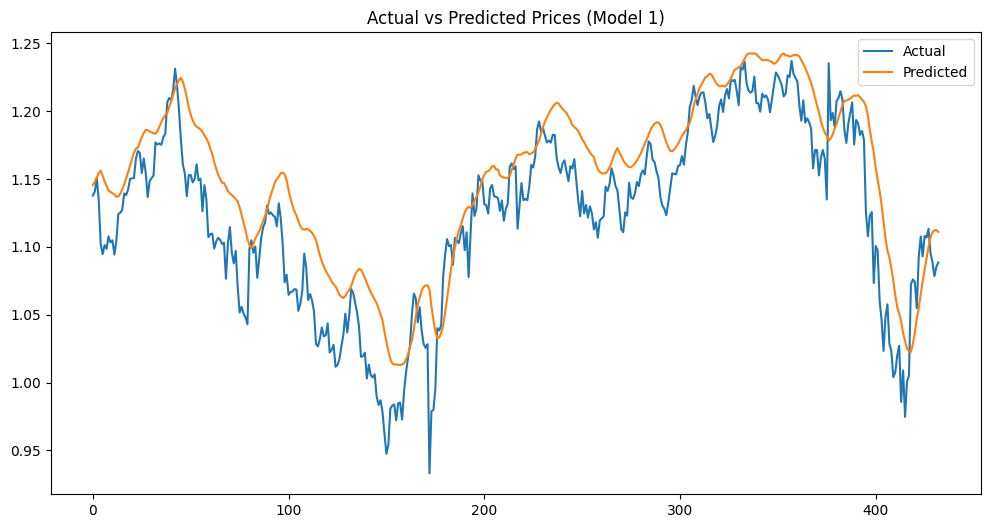

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y1_test, label="Actual")
plt.plot(pred1, label="Predicted")
plt.title("Actual vs Predicted Prices (Model 1)")
plt.legend()
plt.show()

In [67]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["OHLCV", "OHLCV + MA", "OHLCV + MA + Indicators"],
    "MAE": [0.031531, 0.083329, 0.121831],
    "RMSE": [0.038057, 0.090002, 0.126740],
    "R2 Score": [0.677202, -0.793635, -2.534475]
})

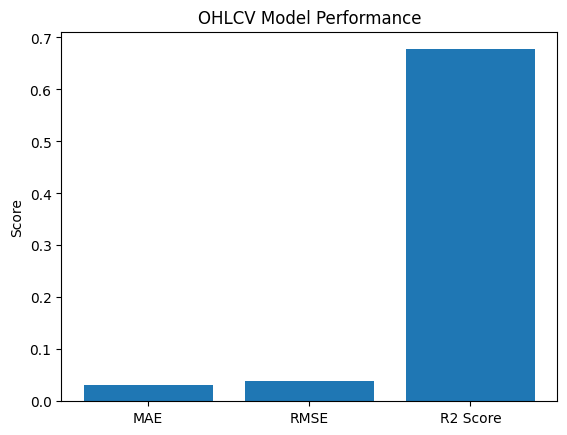

In [72]:
import matplotlib.pyplot as plt

metrics = ["MAE", "RMSE", "R2 Score"]
values = [0.031531, 0.038057, 0.677202]

plt.figure()
plt.bar(metrics, values)
plt.title("OHLCV Model Performance")
plt.ylabel("Score")
plt.show()

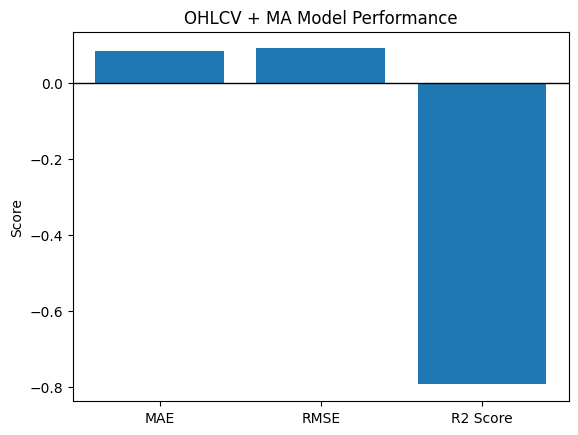

In [73]:
metrics = ["MAE", "RMSE", "R2 Score"]
values = [0.083329, 0.090002, -0.793635]

plt.figure()
plt.bar(metrics, values)
plt.title("OHLCV + MA Model Performance")
plt.ylabel("Score")
plt.axhline(0, color="black", linewidth=1)
plt.show()

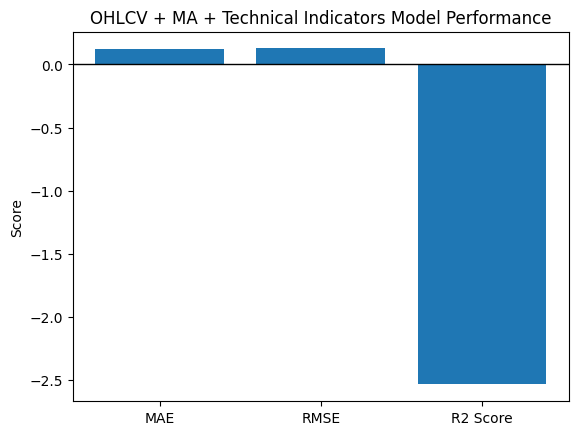

In [74]:
metrics = ["MAE", "RMSE", "R2 Score"]
values = [0.121831, 0.126740, -2.534475]

plt.figure()
plt.bar(metrics, values)
plt.title("OHLCV + MA + Technical Indicators Model Performance")
plt.ylabel("Score")
plt.axhline(0, color="black", linewidth=1)
plt.show()